# Introduction

## MVTec Anomaly Detection

[MVTec AD](https://www.mvtec.com/research-teaching/datasets/mvtec-ad) is a dataset for benchmarking anomaly detection with a focus on industrial inspection. In total, it contains over 5000 high-res images divided into 15 different objects/texture categories consisting of normal, defect-free images intended for training and images with defects for testing. In addition, the dataset provides pixel-precise ground truth for all anamolies.

The goal for this project is NOT to create a state-of-the-art anomaly detector, but rather build a Post-Training Quantization (PTQ) pipeline. We want to see if quantization will degrade the model's ability to correctly detect anomalies and visualize its effect on different layers.

## Why Quantization?

There are two places an AI model can run:

1. **Cloud**: Data is sent over the internet to a powerful server, processed, and results are sent back.
2. **Edge**: Computing happens on the device itself, no internet required.

(write a simple summary)

You can read more [here](https://www.mvtec.com/research-teaching/datasets/mvtec-ad)



# 1.1 Pre-requisites

Please ensure the proper versions are downloaded, which can be found in requirements.txt.

In [66]:
import numpy as np
import sys
import yaml

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

print(torch.__version__)

import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

%load_ext autoreload
%autoreload 2

2.6.0+cu124
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device: %s" % device)

Device: cuda


## 1.2 Dataset Setup and Exploration

In [68]:
# Dataset location
MVT_ROOT = Path("C:/Users/dkim2/Desktop/projects/edge_anomaly/data")
CAT = 'bottle'
DATA_PATH = MVT_ROOT / CAT

# Verify
assert DATA_PATH.exists(), f"{DATA_PATH}\n NOT FOUND"

### 1.2.1 Quick Resolution Verification

In [69]:
img_path = DATA_PATH / "train" / "good" / "000.png"
sample_img = Image.open(img_path)

print(f"Res: {sample_img.size}")
print(f"Mode: {sample_img.mode}")

Res: (900, 900)
Mode: RGB


Downscale to 256x256 and visually verify anomalies are identifiable.

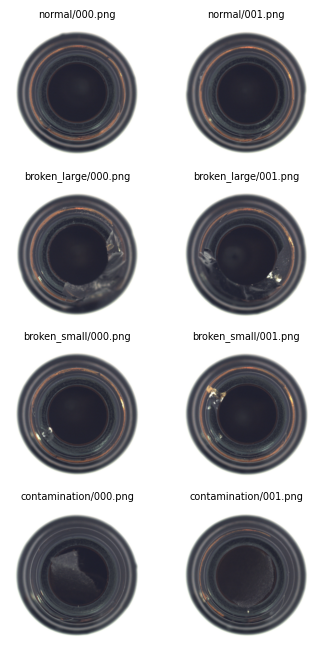

In [70]:
IMG_SIZE = 256

def load_and_resize(category_path: Path, split: str, subfolder: str, size: int, n: int):

    folder = category_path / split / subfolder
    paths = sorted(folder.glob("*.png"))[:n]
    images = [Image.open(path).resize((size, size), Image.BILINEAR) for path in paths]

    return images, [p.name for p in paths]


# Load normal and all anomaly types 256x256
norm_resized, norm_names = load_and_resize(DATA_PATH, "train", "good", size=IMG_SIZE, n=2)

# Anomaly types
anomaly_types = sorted([path.name for path in (DATA_PATH / "test").iterdir() if path.is_dir() and path.name != "good"])

n_cols = 2 # 2 samples per
n_rows = 1 + len(anomaly_types)  # normal row + one row per anomaly type

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

# Normal row
for i, (img, name) in enumerate(zip(norm_resized, norm_names)):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"normal/{name}", fontsize=7)
    axes[0, i].axis("off")

# One row per anomaly
for row, anomaly_type in enumerate(anomaly_types, start=1):
    anom_resized, anom_names = load_and_resize(DATA_PATH, "test", anomaly_type, size=IMG_SIZE, n=2)

    for i, (img, name) in enumerate(zip(anom_resized, anom_names)):
        axes[row, i].imshow(img)
        axes[row, i].set_title(f"{anomaly_type}/{name}", fontsize=7)
        axes[row, i].axis("off")

plt.show()

### 1.2.2 PyTorch Model

Adjusting hyperparameters is done in `config/cnn.yaml`.

In [71]:
config_file = "cnn.yaml" # change value for different configuration
ROOT = Path("C:/Users/dkim2/Desktop/projects/edge_anomaly/") # Project folder root
CONFIG_PATH = ROOT / "config" / config_file

with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)


# 2. Convolution Neural Network

There are two gradients that matter during the backward pass.

1. **Gradient w.r.t weights (how to update kernel)**
$$
\begin{align}
\frac{\partial L}{\partial K[m, n]} = \sum \sum \frac{\partial L}{\partial Out[i, j]} * H[i+m, j+n]
\end{align}
$$

For each kernel weight $K[m,n]$, find every input position it touched during the forward pass and add how much each contributed to the loss. It's essentially the convolution between the input and the upstream gradient.

2. **Gradient w.r.t input (passing loss back to prev. layer)**
$$
\begin{align}
\frac{\partial L}{\partial H[i, j]} = \sum \sum \frac{\partial L}{\partial Out[i, j]} * K[m, n]
\end{align}
$$

For each input pixel, find every output it contributed to and add how much it affected the loss. This is the full convolution.



## 2.1 Verify Shapes and Parameters

In [72]:
sys.path.append(str(Path.cwd().parent / "source"))
 
from torchinfo import summary
from cnn import ConvAutoencoder  # pyright: ignore[reportMissingImports]


model = ConvAutoencoder()
 
summary(model,
        input_size=(1, 3, 256, 256),   # (B, C, H, W)
        col_names=["input_size", "output_size", "num_params"],
        depth=3,
)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ConvAutoencoder                          [1, 3, 256, 256]          [1, 3, 256, 256]          --
├─QuantStub: 1-1                         [1, 3, 256, 256]          [1, 3, 256, 256]          --
├─Encoder: 1-2                           [1, 3, 256, 256]          [1, 512, 8, 8]            --
│    └─Sequential: 2-1                   [1, 3, 256, 256]          [1, 512, 8, 8]            --
│    │    └─Conv2d: 3-1                  [1, 3, 256, 256]          [1, 32, 128, 128]         1,568
│    │    └─BatchNorm2d: 3-2             [1, 32, 128, 128]         [1, 32, 128, 128]         64
│    │    └─ReLU: 3-3                    [1, 32, 128, 128]         [1, 32, 128, 128]         --
│    │    └─Conv2d: 3-4                  [1, 32, 128, 128]         [1, 64, 64, 64]           32,832
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]           [1, 64, 64, 64]           128
│    │    └─ReLU: 3-6      

# 3. Training Model

## 3.1 Model prequisites. Contains relevant paths, classes, and loader

In [73]:
sys.path.append(str(Path.cwd().parent / "data"))

from data_processing import get_dataloader # pyright: ignore[reportMissingImports]
from train import train # pyright: ignore[reportMissingImports]

In [74]:
CHECKPOINT_DIR = ROOT / "checkpoints"
assert CHECKPOINT_DIR.exists(), f"{CHECKPOINT_DIR} -> N/A"

In [75]:
train_loader = get_dataloader(root = DATA_PATH, split = "train", batch_size = cfg["train"]["batch_size"], shuffle = True)

print(f"Batches per epoch: {len(train_loader)}")
print(f"Total images: {len(train_loader.dataset)}")

Batches per epoch: 7
Total images: 209


In [76]:
loss_history = train(model = model, dataloader = train_loader, epochs = cfg["train"]["epochs"],
                     learning_rate = cfg["train"]["learning_rate"], weight_decay = cfg["train"]["weight_decay"],
                     device = device, checkpoint_dir = CHECKPOINT_DIR)

# plt.figure(figsize=(8, 4))
# plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
# plt.title("Training Loss")
# plt.xlabel("Epoch")
# plt.ylabel("MSE Loss")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Epoch 1/100 | Loss: 0.140172


Epoch 2/100 | Loss: 0.112618


Epoch 3/100 | Loss: 0.092268


Epoch 4/100 | Loss: 0.077705


Epoch 5/100 | Loss: 0.067585


...

Epoch 96/100 | Loss: 0.001366


Epoch 97/100 | Loss: 0.001347


Epoch 98/100 | Loss: 0.001327


Epoch 99/100 | Loss: 0.001314


Epoch 100/100 | Loss: 0.001302

Complete. Best loss: 0.001302


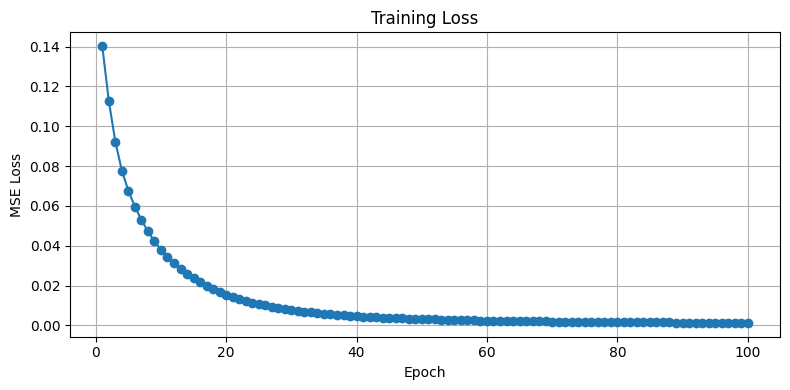

In [77]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Anomaly Detection

The weights are tuned specifically for **normal** images. When the input is a normal image, the output reconstructs that image with a low MSE. When the input image contains an anomaly, due to the weights having been trained on only normal bottles, the model attempts to reconstruct a normal bottle. However, the MSE between the input image and output image will be significantly higher.

The difference in MSE determines if the image has an anomaly. The threshold can then be determined using an ROC curve.



# 5. Quantization Error

## 5.1 Types

### 5.1.1 Weights
From the two equations, we see that both gradients depend directly on $K$ (kernel weights). During quantization, if $K$ is compressed from float32 (32-bit precision) to int8 (256 discreet values), both weight update and backpass information will be affected. The quantization error is the difference between the original and reconstructed. 
$$
\begin{gather}
\text{scale} = \frac{K_{\text{float}}^{\max} - K_{\text{float}}^{\min}}{255}; \quad \text{center} = \text{round}\left(-\frac{K^{\text{min}}}{\text{scale}}\right)\\
K_{\text{int}} = \text{round}\left(\frac{K_{\text{float}}}{\text{scale}}\right) + \text{center}\\
K_{\text{approx}} = \text{scale} * (K_{\text{int}} - \text{center})\\
\text{error} = K_\text{float} - K_\text{approx}
\end{gather}
$$

### 5.1.2 Activation

Let's look at a simple case of activation after convolution `ReLU(conv(input, kernel))`. While weight ranges are fixed after training, activation ranges depends on the `input`, meaning that it changes with every sample. 

There are 3 ways of dealing with this. Post-Training Quantization (PTQ), Quantization-Aware Training (QAT), and Dynamic Quantization (DQ). QAT simulates the quantization noise during training s.t. the model will be robust to it, but at the cost of computation, as the model will need to be retrained. DQ computes ranges during runtime, at the cost of speed.

This notebook will focus on PTQ. Rather than retraining or computing during run time, PTQ uses a calibration dataset, where you run a sample of inputs through the model, record the activation ranges at each layer, then use those to set the parameters.

In [78]:
from quantize import quantize  # pyright: ignore[reportMissingImports]

quantized_model, layer_stats = quantize(checkpoint_path = CHECKPOINT_DIR / "best_model.pth",
                                        calibration_loader = train_loader,
                                        target_layers = cfg["quantize"]["layers"],
                                        backend = cfg["quantize"]["backend"],
                                        n_calibration = cfg["quantize"]["n_calibration"]
                                        )

c:\Users\dkim2\pymc-env\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Calibrating on 100 images across 4 batches...
Quantization complete. Output shape: torch.Size([1, 3, 256, 256])
Layer: encoder.layers.9               Key: activation_scale          Value: 0.02483

Layer: encoder.layers.9               Key: activation_zero_point     Value: 55.00000

Layer: encoder.layers.9               Key: activation_min            Value: -1.39603

Layer: encoder.layers.9               Key: activation_max            Value: 2.11620

Layer: encoder.layers.9               Key: weight_scale              Value: 0.00016

Layer: encoder.layers.9               Key: weight_zero_point         Value: 0.00000

Layer: encoder.layers.12              Key: activation_scale          Value: 0.02369

Layer: encoder.layers.12              Key: activation_zero_point     Value: 57.00000

Layer: encoder.layers.12              Key: activation_min            Value: -1.52494

Layer: encoder.layers.12              Key: activation_max            Value: 1.84140

Layer: encoder.layers.12          

In [79]:
from dequantize import dequantize  # pyright: ignore[reportMissingImports]

# fp32 weights
fp32_weights = {}
checkpoint = torch.load(CHECKPOINT_DIR / "best_model.pth", map_location="cpu")
fp32_model_state = checkpoint["model_state"]

for layer in cfg["quantize"]["layers"]:
    key = layer + ".weight"

    if key in fp32_model_state:
        fp32_weights[layer] = fp32_model_state[key]

# int8 weights
dq_weights = dequantize(quantized_model = quantized_model,
                                 target_layers = cfg["quantize"]["layers"]
                                 )

In [80]:
dq_weights.keys()

dict_keys(['encoder.layers.9', 'encoder.layers.12', 'decoder.layers.0'])

In [81]:
from visualize import (plot_roc_curve,          # pyright: ignore[reportMissingImports]
                       plot_reconstruction,
                       plot_residual_heatmap,
                       plot_weight_error,
                       plot_anomaly_scores
                       )

# Config
ANOMALY_TYPE = "broken_large"   # ← change here to swap anomaly category

test_loader = get_dataloader(
    root = DATA_PATH,
    split = "test",
    batch_size = cfg["train"]["batch_size"],
    shuffle = False,
)

# Images — pull one normal and one anomalous sample
normal_image, _ = train_loader.dataset[0]
anomaly_image, _ = next(
    (img, t) for img, t in test_loader.dataset if t == ANOMALY_TYPE
)

# Test loader
test_loader = get_dataloader(root = DATA_PATH,
                             split = "test",
                             batch_size = cfg["train"]["batch_size"],
                             shuffle = False
                             )

# ROC


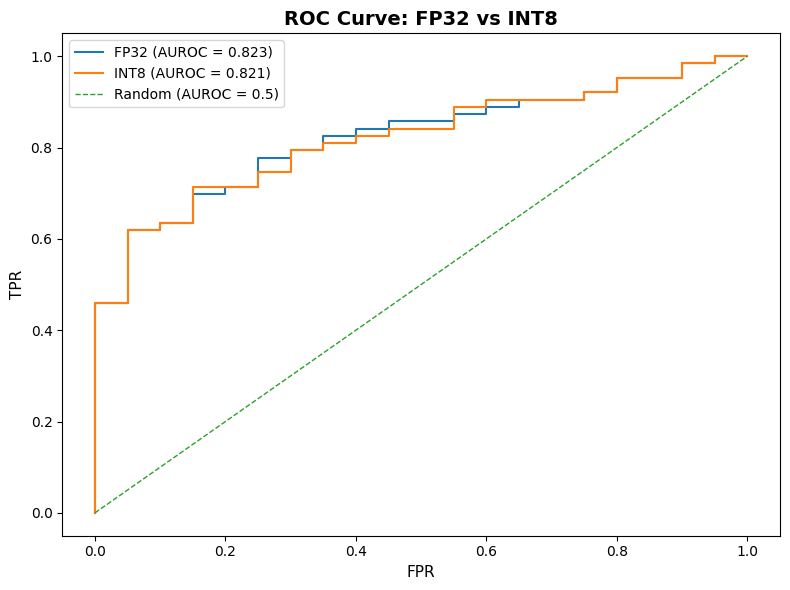

FP32 AUROC : 0.8230
INT8 AUROC : 0.8206
Difference : 0.0024


In [82]:
plot_roc_curve(model, quantized_model, test_loader)

# Output Reconstruction

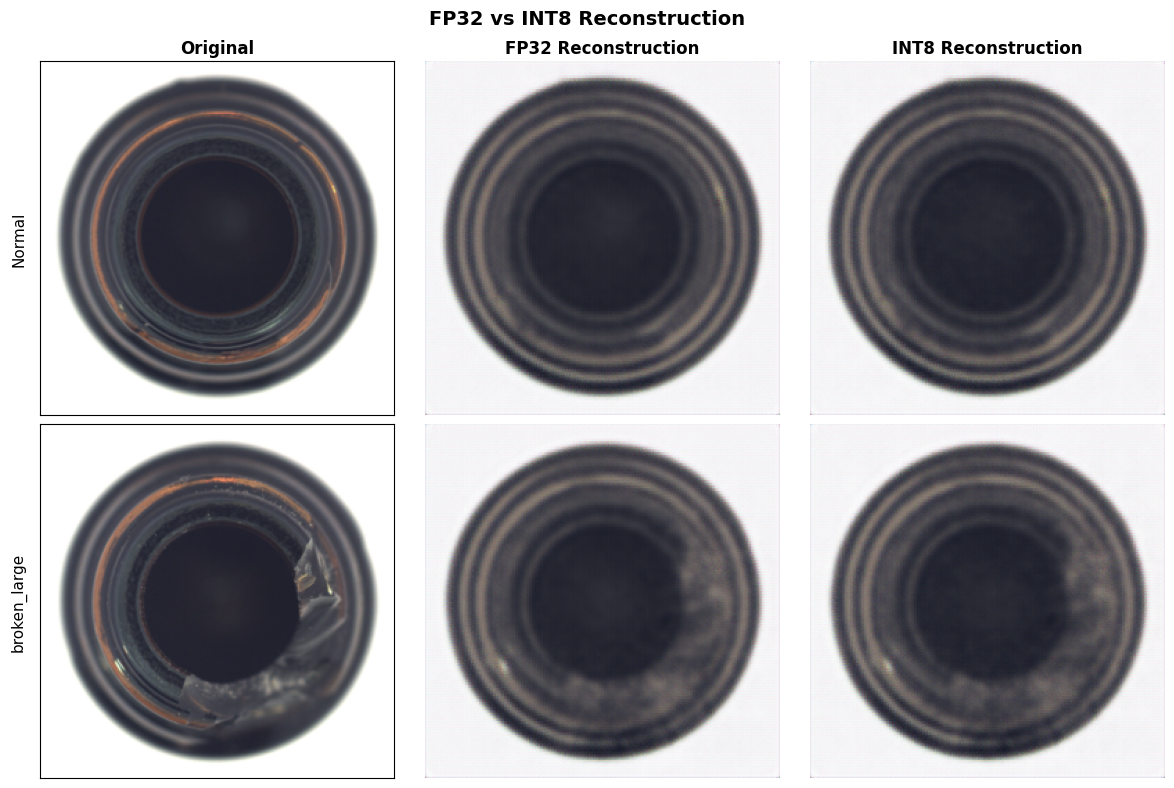

In [83]:
plot_reconstruction(model, quantized_model, normal_image, anomaly_image, ANOMALY_TYPE)

# Heatmap

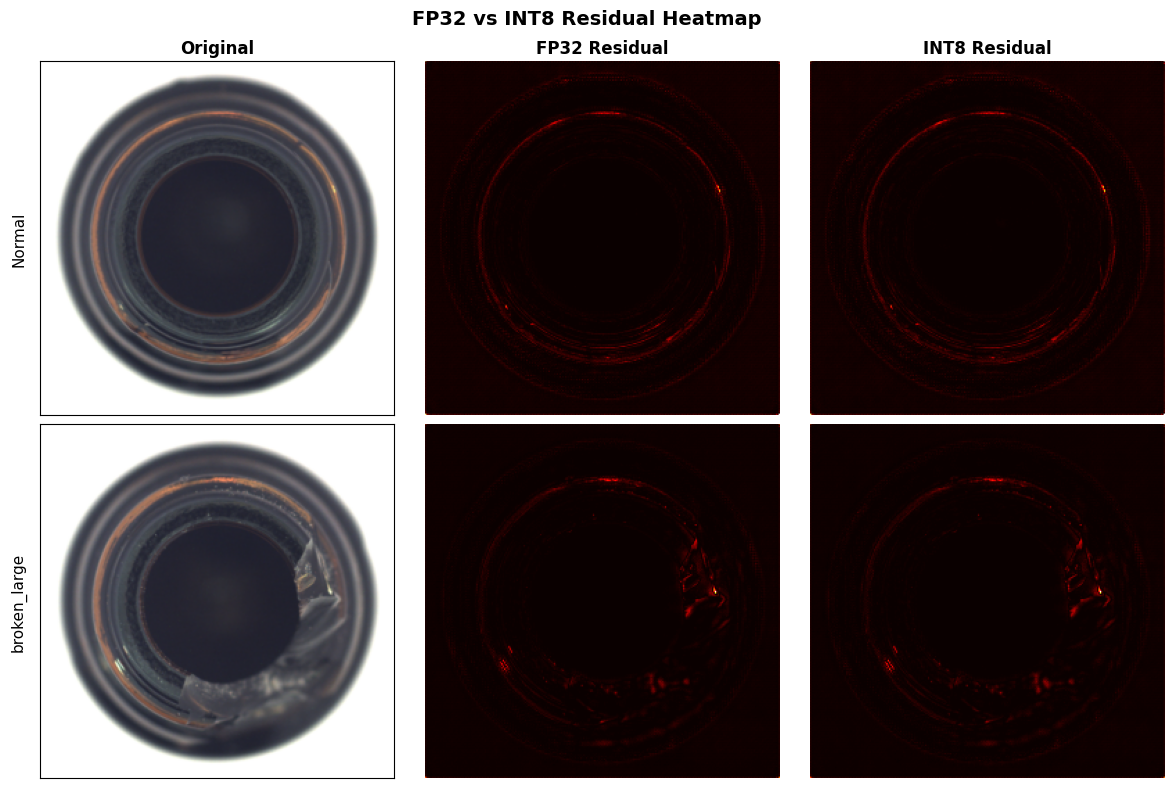

In [84]:
plot_residual_heatmap(model, quantized_model, normal_image, anomaly_image, ANOMALY_TYPE)

# Weight and Anomaly

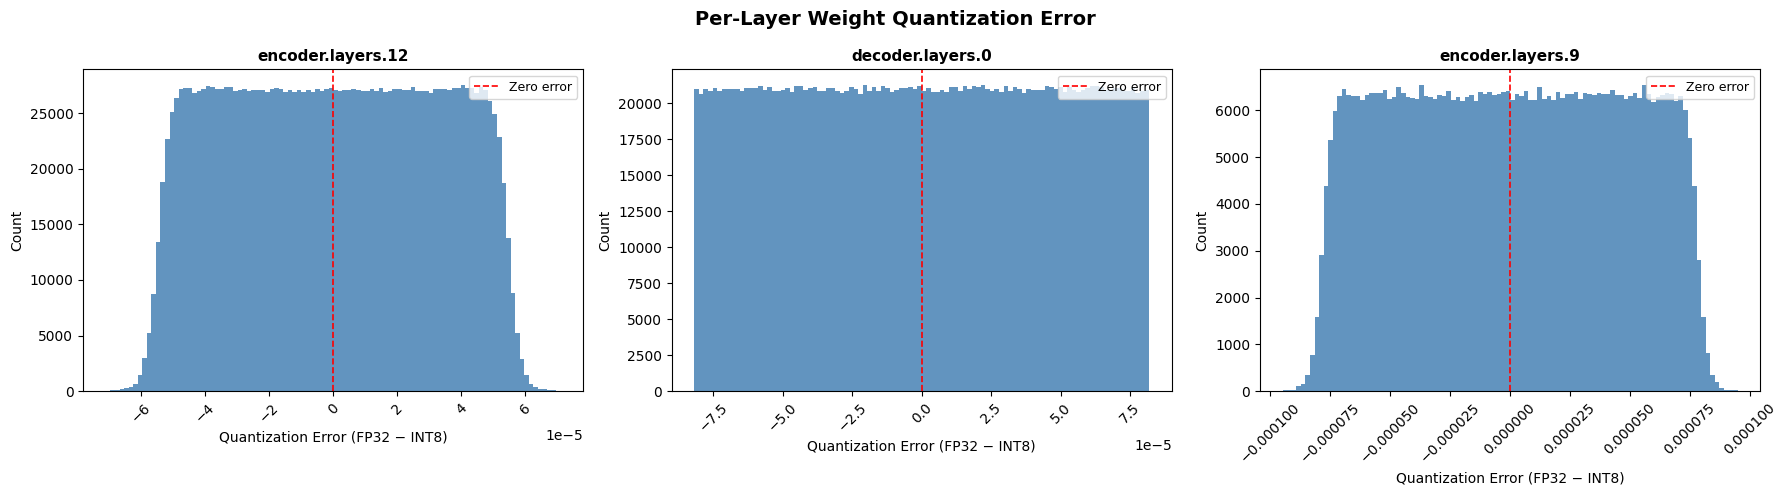

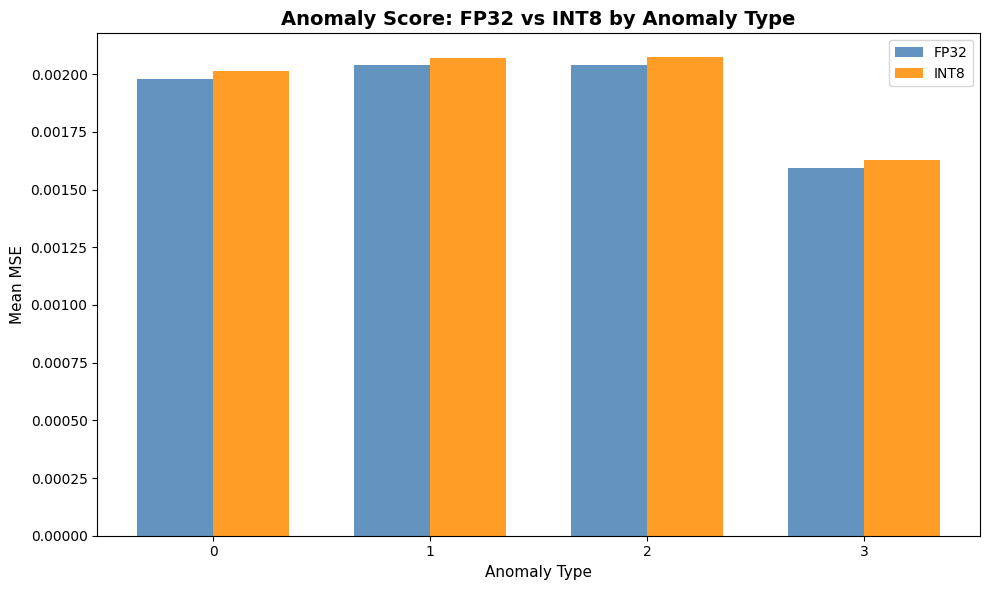

In [85]:
plot_weight_error(fp32_weights, dq_weights)
plot_anomaly_scores(model, quantized_model, test_loader)

# Citations

https://www.cs.toronto.edu/~hinton/absps/science.pdf
https://arxiv.org/pdf/1312.6114
